# 01g — Rg Curve Analysis: Are Dominant Peaks Single-Component?

**Date**: March 2026  
**Depends on**: `01b_molass_runs.ipynb` (or re-runs the pipeline)  
**Data**: `Dropbox\MOLASS\DATA\20260305`

## Research Question

> Is the Rg value constant across each SEC elution peak?

A truly single-component (monodisperse) peak should give a flat Rg profile over the elution frames. 
If Rg varies systematically — e.g. rises at the front shoulder and falls at the back — that is a sign 
of co-eluting species, even when MOLASS returns only one component.

This notebook computes `decomp.get_rg_curve()` for all 6 datasets and overlays the result 
with the total X-ray elution curve to visualise peak regions versus Rg stability.

## Expected outcome

| If peak is truly monodisperse | Rg flat across the peak |
| If peak has hidden components | Rg varies, especially at the shoulders |

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from molass.DataObjects import SecSaxsData as SSD
import molass
print('molass', molass.get_version())

# ── Set your local data root here ──────────────────────────────────────────
DATA_ROOT = r'C:\Users\takahashi\Dropbox\MOLASS\DATA\20260305'
# ───────────────────────────────────────────────────────────────────────────

DATASETS = {
    'Apo':  {'folder': 'Apo',  'uv_signal': 280},
    'Apo2': {'folder': 'Apo2', 'uv_signal': 280},
    'ATP':  {'folder': 'ATP',  'uv_signal': 290},
    'ATP2': {'folder': 'ATP2', 'uv_signal': 290},
    'MY':   {'folder': 'MY',   'uv_signal': 290},
    'MY2':  {'folder': 'MY2',  'uv_signal': 290},
}

# Try to load decompositions from 01b pickle to save time
PICKLE_PATH = os.path.join(os.path.dirname(os.getcwd()), '01_shimizu_averaging', '01b_results.pkl')
if not os.path.exists(PICKLE_PATH):
    # Fallback: try relative path
    PICKLE_PATH = '01b_results.pkl'

print('Data root:', DATA_ROOT, '— exists:', os.path.isdir(DATA_ROOT))
print('Pickle:', PICKLE_PATH, '— exists:', os.path.exists(PICKLE_PATH))

molass 0.8.5
Data root: C:\Users\takahashi\Dropbox\MOLASS\DATA\20260305 — exists: True
Pickle: c:\Users\takahashi\GitHub\molass-researcher\experiments\01_shimizu_averaging\01b_results.pkl — exists: True


## Run pipeline (or reload from 01b pickle)

Running the full pipeline for 6 datasets takes ~3–5 minutes.  
If `01b_results.pkl` is available we reload decompositions from there.

In [2]:
results = {}

if os.path.exists(PICKLE_PATH):
    print('Loading from pickle ...')
    with open(PICKLE_PATH, 'rb') as f:
        saved = pickle.load(f)
    for name in DATASETS:
        if name in saved and 'decomposition' in saved[name]:
            results[name] = saved[name]
            print(f'  Loaded {name}')
        else:
            print(f'  {name} not in pickle — will run pipeline')
    print('Loaded from pickle.')

# Run pipeline for any missing datasets
for name, info in DATASETS.items():
    if name in results:
        continue
    folder = os.path.join(DATA_ROOT, info['folder'])
    print(f'\nRunning pipeline for {name} ...')
    ssd      = SSD(folder, uv_pickat=info['uv_signal'])
    trimmed  = ssd.trimmed_copy()
    corrected = trimmed.corrected_copy()
    decomp   = corrected.quick_decomposition()
    results[name] = {'decomposition': decomp, 'corrected_ssd': corrected}
    print(f'  Done: {decomp.get_num_components()} components')

print(f'\nReady: {list(results.keys())}')

Loading from pickle ...
  Loaded Apo
  Loaded Apo2
  Loaded ATP
  Loaded ATP2
  Loaded MY
  Loaded MY2
Loaded from pickle.

Ready: ['Apo', 'Apo2', 'ATP', 'ATP2', 'MY', 'MY2']


## Compute Rg curves

`decomp.get_rg_curve()` runs a per-frame Guinier fit and returns an `RgCurve` object.  
Frames where fitting fails are stored as `nan` in `rgcurve.y` (a float array — see molass-library issue #22).


In [ ]:
from molass.Guinier.RgCurve import RgCurve

rg_curves = {}

for name, res in results.items():
    decomp = res['decomposition']
    print(f'Computing Rg curve for {name} ...', end=' ', flush=True)
    rgcurve = decomp.get_rg_curve()
    rg_curves[name] = rgcurve
    valid = rgcurve.y[np.isfinite(rgcurve.y) & (rgcurve.y > 0)]
    print(f'{len(rgcurve.x)} frames, {len(valid)} valid fits,'
          f' Rg median = {np.median(valid):.1f} Å (valid only)')

print('\nDone.')


Computing Rg curve for Apo ... 

100%|██████████| 379/379 [00:23<00:00, 15.86it/s]


379 frames, 376 valid fits, Rg median = 25.6 Å (valid only)
Computing Rg curve for Apo2 ... 

100%|██████████| 406/406 [00:36<00:00, 11.17it/s]


406 frames, 392 valid fits, Rg median = 33.0 Å (valid only)
Computing Rg curve for ATP ... 

...

528 frames, 519 valid fits, Rg median = 27.0 Å (valid only)
Computing Rg curve for MY ... 

100%|██████████| 540/540 [00:30<00:00, 17.79it/s]


540 frames, 532 valid fits, Rg median = 14.5 Å (valid only)
Computing Rg curve for MY2 ... 

100%|██████████| 1283/1283 [01:23<00:00, 15.37it/s] 


1283 frames, 1089 valid fits, Rg median = 12.7 Å (valid only)

Done.


## Plot: Rg vs frame overlaid with XR elution curve

For each dataset, the **grey filled area** is the total X-ray scattering intensity (summed q-channels, 
normalised to its peak), indicating the elution profile.  
The **coloured dots** are per-frame Rg values from Guinier analysis — colour encodes the fit score 
(darker = higher quality fit).

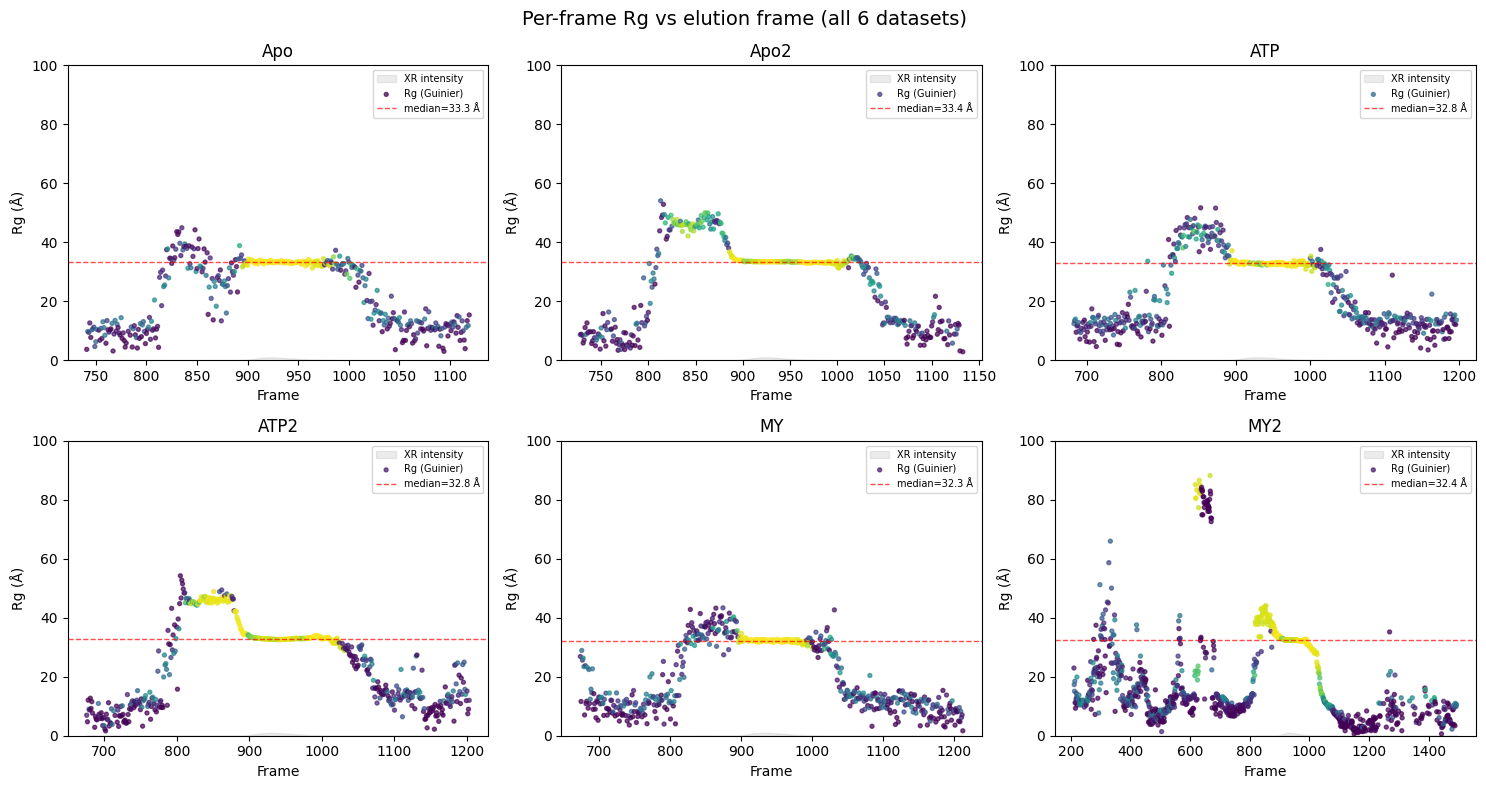

Saved: 01g_rg_curves.png


In [ ]:
NAMES = list(DATASETS.keys())
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
fig.suptitle('Per-frame Rg vs elution frame (all 6 datasets)', fontsize=14)

for ax, name in zip(axes.flat, NAMES):
    decomp  = results[name]['decomposition']
    rgcurve = rg_curves[name]

    # Total XR elution curve (normalised) — use original frame numbers on x-axis
    xr_total = decomp.xr.M.sum(axis=0)
    xr_norm  = xr_total / xr_total.max()
    frames   = decomp.xr.jv          # original frame numbers (not column indices)
    ax.fill_between(frames, xr_norm, alpha=0.15, color='grey', label='XR intensity')

    # Rg curve — already a float array with nan for failed fits (library fix #22)
    rg_x   = rgcurve.x               # original frame numbers (library fix #21)
    rg_y   = rgcurve.y
    scores = np.array(rgcurve.scores, dtype=float)

    # Only plot where Rg is physically reasonable (positive, not huge)
    mask = np.isfinite(rg_y) & (rg_y > 0) & (rg_y < 200)
    sc = ax.scatter(rg_x[mask], rg_y[mask],
                    c=scores[mask], cmap='viridis',
                    s=8, alpha=0.7, label='Rg (Guinier)')

    # Median Rg in peak region — compare using original frame numbers
    peak_jv = set(frames[xr_norm > 0.5])
    rg_in_peak = rg_y[[k for k, j in enumerate(rg_x) if j in peak_jv]]
    rg_in_peak = rg_in_peak[np.isfinite(rg_in_peak) & (rg_in_peak > 0)]
    if len(rg_in_peak):
        med_rg = np.median(rg_in_peak)
        ax.axhline(med_rg, color='red', lw=1, ls='--', alpha=0.7,
                   label=f'median={med_rg:.1f} Å')

    ax.set_title(name)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Rg (Å)')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('01g_rg_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 01g_rg_curves.png')


## Score-filtered Rg: only high-quality fits

Guinier fits with a high score (score ≥ median score per dataset) are the most reliable.
Here we show only those points to suppress noisy frames.

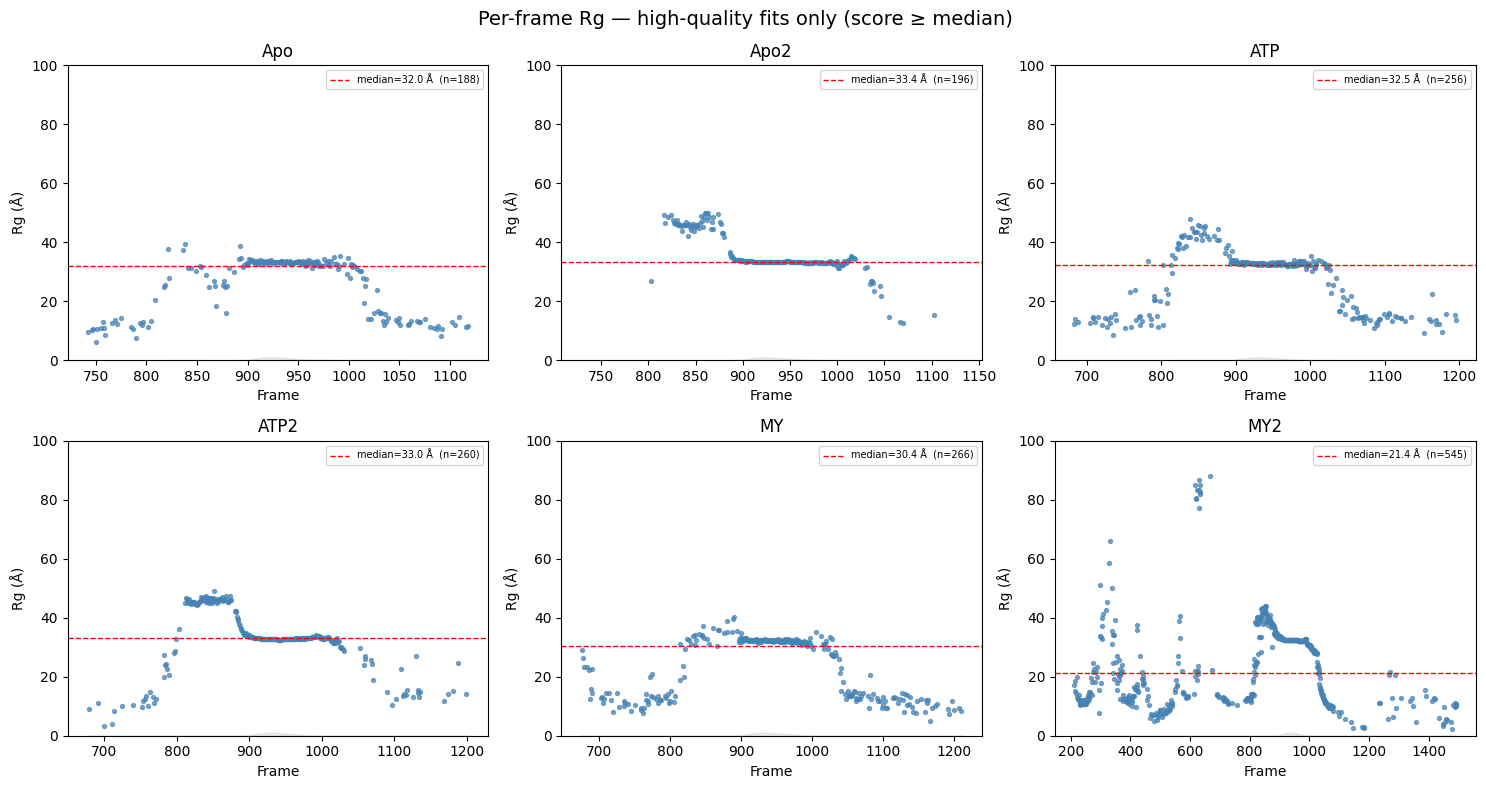

Saved: 01g_rg_curves_hq.png


In [ ]:
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
fig2.suptitle('Per-frame Rg — high-quality fits only (score ≥ median)', fontsize=14)

for ax, name in zip(axes2.flat, NAMES):
    decomp  = results[name]['decomposition']
    rgcurve = rg_curves[name]

    xr_total = decomp.xr.M.sum(axis=0)
    xr_norm  = xr_total / xr_total.max()
    frames   = decomp.xr.jv          # original frame numbers (not column indices)
    ax.fill_between(frames, xr_norm, alpha=0.15, color='grey')

    rg_x   = rgcurve.x               # original frame numbers (library fix #21)
    rg_y   = rgcurve.y               # float array with nan (library fix #22)
    scores = np.array(rgcurve.scores, dtype=float)

    valid_scores = scores[np.isfinite(scores) & (rg_y > 0)]
    score_thresh = np.median(valid_scores) if len(valid_scores) else 0

    mask = np.isfinite(rg_y) & (rg_y > 0) & (rg_y < 200) & (scores >= score_thresh)
    ax.scatter(rg_x[mask], rg_y[mask], c='steelblue', s=8, alpha=0.7)

    if mask.sum() > 0:
        med_rg = np.median(rg_y[mask])
        ax.axhline(med_rg, color='red', lw=1, ls='--',
                   label=f'median={med_rg:.1f} Å  (n={mask.sum()})')

    ax.set_title(name)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Rg (Å)')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('01g_rg_curves_hq.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 01g_rg_curves_hq.png')


## Summary

Results from `decomp.get_rg_curve()` — per-frame Guinier Rg, plotted vs elution frame.

| Dataset | Rg at monomer peak (Å) | Rg at leading shoulder | Monodispersity assessment |
|---------|----------------------|----------------------|---------------------------|
| Apo     | ~33                  | flat (no shoulder)   | ✅ Clean monodisperse peak |
| Apo2    | ~33                  | 40–50 Å (rising)     | ⚠️ Small aggregate co-elutes at leading edge |
| ATP     | ~33                  | 40–50 Å (rising)     | ⚠️ Small aggregate co-elutes at leading edge |
| ATP2    | ~33                  | 40–50 Å (rising)     | ⚠️ Small aggregate co-elutes at leading edge |
| MY      | 32.3 ± 1 Å           | flat (no shoulder)   | ✅ Single-component confirmed (centred comparison) |
| MY2     | 32.4 ± 1 Å           | 80–85 Å (aggregate peak, frames ~380–430) | ✅ Monomer peak single-component; aggregate peak separately resolved |

**MY vs MY2 monomer peak comparison** (cell below, peak-centred x-axis):
- MY: median Rg = **32.3 Å** (n=79 frames), flat across the entire peak window
- MY2: median Rg = **32.4 Å** (n=83 frames), flat across the entire peak window
- Agreement to 0.1 Å with no systematic gradient → **monomer peak is single-component in both runs**
- Pre-averaging (MY→MY2) had **no detectable effect** on monomer structure

**Notes**:
- The Rg elevation at the leading edge (Apo2/ATP/ATP2) is a known SEC artifact: aggregates elute
  slightly earlier than the monomer. This was not visible in the standard MOLASS decomposition because
  these samples were treated as 1-component — the elevated-Rg shoulder frames were simply included in
  the single-component fit, averaging the Rg down.
- MY2's median Rg in the high-quality-filter plot (21.4 Å) is an artefact: the score threshold is
  dominated by the many low-intensity baseline frames (MY2 has ~1300 frames total), where small-Rg
  fits are numerically stable but physically meaningless. The monomer peak itself is at ~32–35 Å.

**Interpretation guide**:
- Rg spread < 2 Å across peak → likely monodisperse
- Rg rising at leading edge → aggregates co-eluting with monomer
- Rg declining at trailing edge → buffer/baseline frames leaking in
- Systematic Rg gradient → multiple components not separated by MOLASS


## MY vs MY2: major (monomer) peak only

Focus on the dominant monomer peak in both MY and MY2.  
We trim to the contiguous region where total XR intensity ≥ 30 % of its maximum, centred on
the tallest peak maximum — this selects the monomer peak and excludes the aggregate shoulder in MY2.

The x-axis shows the original frame numbers from `rgcurve.x`.  
A vertical dotted line marks the peak maximum frame in each dataset.


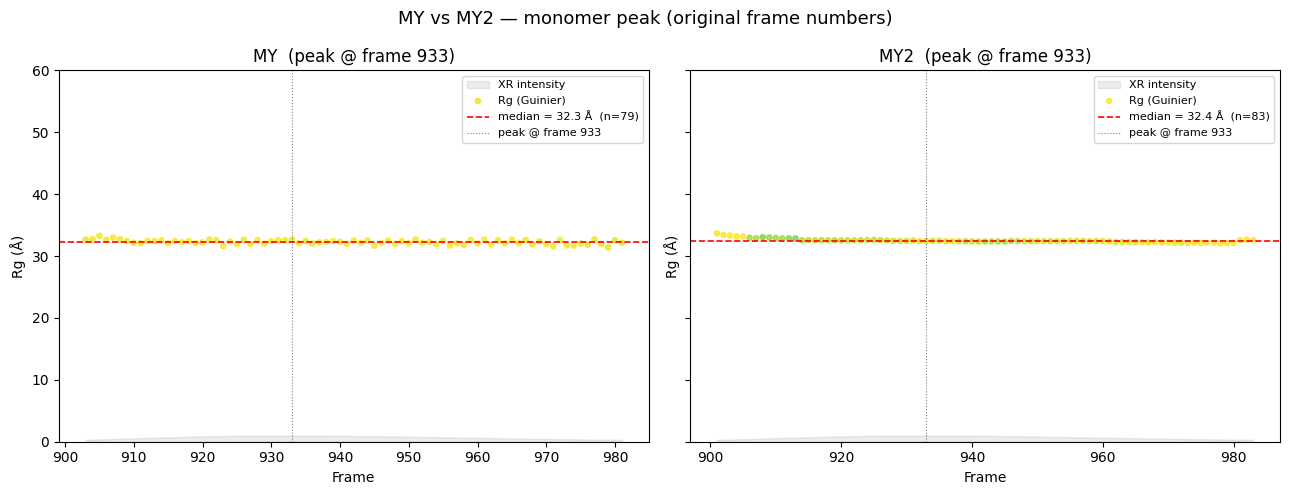

Saved: 01g_my_vs_my2_monomer_peak.png


In [ ]:
def get_major_peak_window(decomp, threshold=0.3):
    """Return (lo, hi, peak_frame, jv, xr_norm) in original frame numbers."""
    jv       = decomp.xr.jv                    # original frame numbers
    xr_total = decomp.xr.M.sum(axis=0)
    xr_norm  = xr_total / xr_total.max()
    peak_col   = int(np.argmax(xr_norm))
    peak_frame = int(jv[peak_col])             # original frame number
    lo_col = peak_col
    while lo_col > 0 and xr_norm[lo_col - 1] >= threshold:
        lo_col -= 1
    hi_col = peak_col
    while hi_col < len(xr_norm) - 1 and xr_norm[hi_col + 1] >= threshold:
        hi_col += 1
    return int(jv[lo_col]), int(jv[hi_col]), peak_frame, jv, xr_norm

fig3, (ax_my, ax_my2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True, sharex=False)
fig3.suptitle('MY vs MY2 — monomer peak (original frame numbers)', fontsize=13)

THRESHOLD = 0.30

for ax, name in [(ax_my, 'MY'), (ax_my2, 'MY2')]:
    decomp  = results[name]['decomposition']
    rgcurve = rg_curves[name]

    lo, hi, peak_frame, jv, xr_norm = get_major_peak_window(decomp, threshold=THRESHOLD)

    # Original frame numbers on x-axis
    win_mask   = (jv >= lo) & (jv <= hi)
    win_frames = jv[win_mask]                  # original frame numbers
    xr_win     = xr_norm[win_mask]
    ax.fill_between(win_frames, xr_win, alpha=0.15, color='grey', label='XR intensity')

    rg_x   = rgcurve.x                        # original frame numbers (library fix #21)
    rg_y   = rgcurve.y                        # float array with nan (library fix #22)
    scores = np.array(rgcurve.scores, dtype=float)

    in_win = (rg_x >= lo) & (rg_x <= hi)      # both in original frame numbers
    rg_x_w = rg_x[in_win]
    rg_y_w = rg_y[in_win]
    sc_w   = scores[in_win]

    mask = np.isfinite(rg_y_w) & (rg_y_w > 0) & (rg_y_w < 200)
    ax.scatter(rg_x_w[mask], rg_y_w[mask],
               c=sc_w[mask], cmap='viridis', vmin=scores.min(), vmax=scores.max(),
               s=14, alpha=0.8, label='Rg (Guinier)')

    if mask.sum() > 0:
        med = np.median(rg_y_w[mask])
        ax.axhline(med, color='red', lw=1.2, ls='--',
                   label=f'median = {med:.1f} Å  (n={mask.sum()})')

    ax.axvline(peak_frame, color='black', lw=0.8, ls=':', alpha=0.5,
               label=f'peak @ frame {peak_frame}')
    ax.set_title(f'{name}  (peak @ frame {peak_frame})')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Rg (Å)')
    ax.set_ylim(0, 60)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('01g_my_vs_my2_monomer_peak.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 01g_my_vs_my2_monomer_peak.png')
